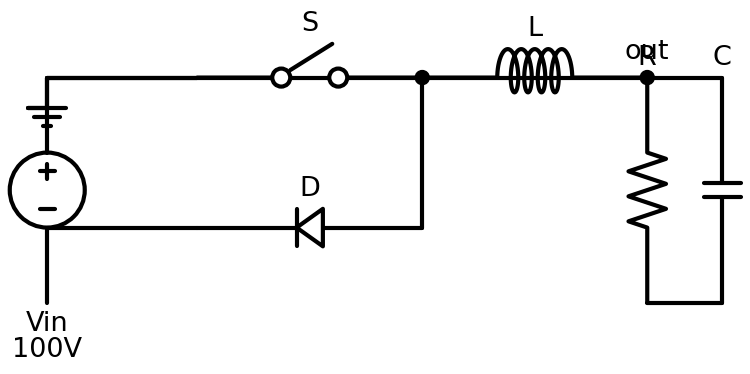

In [1]:
import schemdraw
import schemdraw.elements as elm
import matplotlib.pyplot as plt
from IPython.display import Image, display

with schemdraw.Drawing(show=False) as d:
    d.config(fontsize=13)
    Vin = d.add(elm.SourceV().up().label('Vin\n100V', loc='left'))
    d.add(elm.Line().right(2))
    d.add(elm.Switch().right().label('S', loc='top'))
    sw = d.add(elm.Dot())
    d.add(elm.Inductor2().right().label('L', loc='top'))
    d.add(elm.Dot().label('out', loc='top'))
    d.add(elm.Line().right(1))
    d.add(elm.Capacitor().down().label('C', loc='right'))
    d.add(elm.Line().left(1))
    d.add(elm.Resistor().up().label('R', loc='right'))
    d.add(elm.Line().left().tox(Vin.start))
    d.add(elm.Ground())
    d.add(elm.Line().at(sw.end).down(2))
    d.add(elm.Diode().left().label('D', loc='top'))
    d.add(elm.Line().left().tox(Vin.start))
    d.save('buck_ccm_1_fig.png', dpi=150)

display(Image('buck_ccm_1_fig.png', width=300))

In [2]:
%pycat buck_ccm_1_orig.in

Buck Converter CCM
Vin in 0 DC $VIN
Vpwm gate 0 PULSE(0 5 0 1n 1n $TON $T)
S1 in sw gate 0 SWMOD
D1 0 sw DMOD
L1 sw out $L IC=0
C1 out 0 $C IC=0
RL out 0 $R
.MODEL SWMOD SW(Ron=0.01 Roff=1MEG Vt=2.5)
.MODEL DMOD D(Is=1n N=1 Rs=0.01)
.SAVE $SAVE_VARS
.TRAN $TSTEP $TEND UIC
.END


In [3]:
import numpy as np


Vin = 100.0
Vout = 25.0
R = 2.5
fs = 10e3

T = 1/fs
D = Vout/Vin
Iout = Vout/R

dIL_ratio = 0.20
dVc = 0.1

dIL = dIL_ratio * Iout
L = (Vin - Vout)*D / (fs * dIL)
C = dIL / (8 * fs * dVc)

IL_peak = Iout + dIL/2
IL_min = Iout - dIL/2
Ton = D * T
Tstep = T / 200
Tend = 50 * T

print(f'D = {D:.4f}')
print(f'Iout = {Iout:.4f} A')
print(f'dIL = {dIL:.4f} A')
print(f'IL_peak = {IL_peak:.4f} A')
print(f'IL_min = {IL_min:.4f} A')
print(f'L = {L*1e3:.4f} mH')
print(f'C = {C*1e6:.4f} uF')
print(f'T = {T*1e6:.2f} us')
print(f'Ton = {Ton*1e6:.2f} us')

D = 0.2500
Iout = 10.0000 A
dIL = 2.0000 A
IL_peak = 11.0000 A
IL_min = 9.0000 A
L = 0.9375 mH
C = 250.0000 uF
T = 100.00 us
Ton = 25.00 us


In [4]:
import ngspice_calc as calc

l = [
    ('$VIN', f'{Vin}'),
    ('$TON', f'{Ton:.8f}'),
    ('$T', f'{T:.8f}'),
    ('$L', f'{L:.8f}'),
    ('$C', f'{C:.8f}'),
    ('$R', f'{R}'),
    ('$TSTEP', f'{Tstep:.8f}'),
    ('$TEND', f'{Tend:.6f}'),
    ('$SAVE_VARS', 'v(out), v(sw), i(l1), i(s1), i(d1), i(c1)')
]

calc.replace_strings_1('buck_ccm_1_orig.in', 'buck_ccm_1.in', l)
print('buck_ccm_1.in is ready for execution')

buck_ccm_1.in is ready for execution


In [5]:
calc.run_ngspice('buck_ccm_1.in')


Note: No compatibility mode selected!


Circuit: buck converter ccm

binary raw file "buck_ccm_1.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 4  
Operating point simulation skipped by 'uic',
  now using transient initial conditions.

No. of Data Rows : 12584

Total analysis time (seconds) = 0.0680356

Total elapsed time (seconds) = 0.072 

Total DRAM available = 15614.742 MB.
DRAM currently available = 2920.961 MB.
Maximum ngspice program size =   21.406 MB.
Current ngspice program size =   12.844 MB.

Shared ngspice pages =   11.062 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.879 MB.




'buck_ccm_1.raw'

In [6]:
s = calc.slv('buck_ccm_1.in')
print('Variables:', s.variables())

Variables: ['time', 'v(out)', 'v(sw)', 'i(l1)']


In [8]:
t = s.get_array('time')
Vout_sim = s.get_array('v(out)')
IL_sim = s.get_array('i(l1)')

# steady state = last 2 switching cycles
mask = t >= t[-1] - 2 * T
t_ss = t[mask]
Vout_ss = Vout_sim[mask]
IL_ss = IL_sim[mask]

avg_V, rms_V = calc.avg_rms(t, Vout_sim, t_start=t_ss[0], t_end=t_ss[-1])
avg_I, rms_I = calc.avg_rms(t, IL_sim,   t_start=t_ss[0], t_end=t_ss[-1])

print(f'Vout avg (steady state) = {avg_V:.4f} V  (target: {Vout} V)')
print(f'IL avg (steady state) = {avg_I:.4f} A  (target: {Iout:.4f} A)')
print(f'IL rms (steady state) = {rms_I:.4f} A')

Vout avg (steady state) = 24.9092 V  (target: 25.0 V)
IL avg (steady state) = 9.9665 A  (target: 10.0000 A)
IL rms (steady state) = 9.9839 A


In [9]:
print("t range:", t[0], t[-1])
print("Vout min/max:", np.min(Vout_sim), np.max(Vout_sim))
print("IL min/max:", np.min(IL_sim), np.max(IL_sim))
print("t_ss[0]:", t_ss[0])
print("len(t_ss):", len(t_ss))

t range: 1.0000000000000001e-11 0.005
Vout min/max: 4.2215894229662826e-14 30.96705324000776
IL min/max: 1.055397372627928e-06 16.289255130238583
t_ss[0]: 0.0048000000000000004
len(t_ss): 482


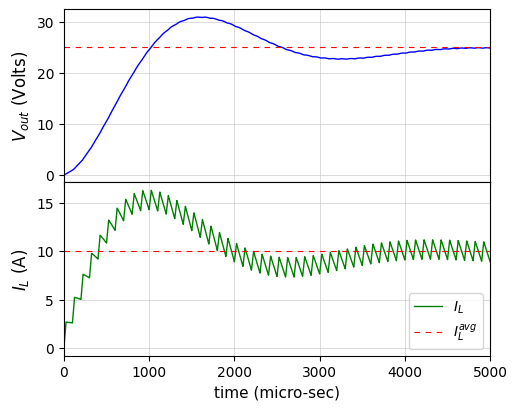

In [10]:
import matplotlib.pyplot as plt

color1 = 'blue'
color2 = 'green'
color3 = 'red'

fig, ax = plt.subplots(2, sharex=False, figsize=(5.5, 4.5))
plt.subplots_adjust(wspace=0, hspace=0.0)

for i in range(2):
    ax[i].set_xlim(left=0.0, right=t[-1] * 1e6)
    ax[i].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

ax[0].set_ylabel(r'$V_{out}$ (Volts)', fontsize=12)
ax[1].set_ylabel(r'$I_L$ (A)', fontsize=12)
ax[0].tick_params(labelbottom=False)

ax[0].plot(t * 1e6, Vout_sim, color=color1, linewidth=1.0, label=r'$V_{out}$')
ax[1].plot(t * 1e6, IL_sim,   color=color2, linewidth=1.0, label=r'$I_L$')

ax[0].axhline(y=Vout,  color=color3, linestyle='--', linewidth=0.8, dashes=(5, 5))
ax[1].axhline(y=avg_I, color=color3, linestyle='--', linewidth=0.8, dashes=(5, 5),
              label=r'$I_L^{avg}$')

ax[1].set_xlabel('time (micro-sec)', fontsize=11)
ax[1].legend(loc='lower right', fontsize=10)

plt.show()